<a href="https://colab.research.google.com/github/Bishre313/testing/blob/main/AETS3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('/content/eVED_181107_week.csv')
df.head()

,DayNum,VehId,Trip,Timestamp(ms),Latitude[deg],Longitude[deg],Vehicle Speed[km/h],MAF[g/sec],Engine RPM[RPM],Absolute Load[%],...,Energy_Consumption,Matchted Latitude[deg],Matched Longitude[deg],Match Type,Class of Speed Limit,Speed Limit[km/h],Speed Limit with Direction[km/h],Intersection,Bus Stops,Focus Points
0,372.882455,10.0,3263.0,0.0,42.295477,-83.705005,32.079998,NaN,NaN,NaN,...,0.004811,42.295487,-83.704927,0,0.0,64,64.0,NaN,NaN,NaN
1,372.882455,10.0,3263.0,900.0,42.295477,-83.705005,35.730000,NaN,NaN,NaN,...,0.004811,42.295487,-83.704927,1,0.0,64,64.0,NaN,NaN,NaN
2,372.882455,10.0,3263.0,1100.0,42.295477,-83.705005,35.730000,NaN,NaN,NaN,...,0.005334,42.295487,-83.704927,1,0.0,64,64.0,NaN,NaN,NaN
3,372.882455,10.0,3263.0,2000.0,42.295477,-83.705005,38.770000,NaN,NaN,NaN,...,0.005334,42.295487,-83.704927,1,0.0,64,64.0,NaN,NaN,NaN
4,372.882455,10.0,3263.0,2100.0,42.295477,-83.705005,38.770000,NaN,NaN,NaN,...,0.005857,42.295487,-83.704927,1,0.0,64,64.0,NaN,NaN,NaN


In [ ]:
# Fill missing values
df = df.fillna(method='ffill').fillna(method='bfill')

# Convert timestamp if present
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['hour'] = df['timestamp'].dt.hour
    df['dayofweek'] = df['timestamp'].dt.dayofweek

df.head()

/tmp/ipython-input-2920257312.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


,DayNum,VehId,Trip,Timestamp(ms),Latitude[deg],Longitude[deg],Vehicle Speed[km/h],MAF[g/sec],Engine RPM[RPM],Absolute Load[%],...,Energy_Consumption,Matchted Latitude[deg],Matched Longitude[deg],Match Type,Class of Speed Limit,Speed Limit[km/h],Speed Limit with Direction[km/h],Intersection,Bus Stops,Focus Points
0,372.882455,10.0,3263.0,0.0,42.295477,-83.705005,32.079998,10.51,1475.0,9.803922,...,0.004811,42.295487,-83.704927,0,0.0,64,64.0,1.0,1.0,traffic_signals
1,372.882455,10.0,3263.0,900.0,42.295477,-83.705005,35.730000,10.51,1475.0,9.803922,...,0.004811,42.295487,-83.704927,1,0.0,64,64.0,1.0,1.0,traffic_signals
2,372.882455,10.0,3263.0,1100.0,42.295477,-83.705005,35.730000,10.51,1475.0,9.803922,...,0.005334,42.295487,-83.704927,1,0.0,64,64.0,1.0,1.0,traffic_signals
3,372.882455,10.0,3263.0,2000.0,42.295477,-83.705005,38.770000,10.51,1475.0,9.803922,...,0.005334,42.295487,-83.704927,1,0.0,64,64.0,1.0,1.0,traffic_signals
4,372.882455,10.0,3263.0,2100.0,42.295477,-83.705005,38.770000,10.51,1475.0,9.803922,...,0.005857,42.295487,-83.704927,1,0.0,64,64.0,1.0,1.0,traffic_signals


In [ ]:
# Create acceleration from speed if not available
if 'speed' in df.columns:
    df['acceleration_calc'] = df['speed'].diff().fillna(0)

df.head()

,DayNum,VehId,Trip,Timestamp(ms),Latitude[deg],Longitude[deg],Vehicle Speed[km/h],MAF[g/sec],Engine RPM[RPM],Absolute Load[%],...,Energy_Consumption,Matchted Latitude[deg],Matched Longitude[deg],Match Type,Class of Speed Limit,Speed Limit[km/h],Speed Limit with Direction[km/h],Intersection,Bus Stops,Focus Points
0,372.882455,10.0,3263.0,0.0,42.295477,-83.705005,32.079998,10.51,1475.0,9.803922,...,0.004811,42.295487,-83.704927,0,0.0,64,64.0,1.0,1.0,traffic_signals
1,372.882455,10.0,3263.0,900.0,42.295477,-83.705005,35.730000,10.51,1475.0,9.803922,...,0.004811,42.295487,-83.704927,1,0.0,64,64.0,1.0,1.0,traffic_signals
2,372.882455,10.0,3263.0,1100.0,42.295477,-83.705005,35.730000,10.51,1475.0,9.803922,...,0.005334,42.295487,-83.704927,1,0.0,64,64.0,1.0,1.0,traffic_signals
3,372.882455,10.0,3263.0,2000.0,42.295477,-83.705005,38.770000,10.51,1475.0,9.803922,...,0.005334,42.295487,-83.704927,1,0.0,64,64.0,1.0,1.0,traffic_signals
4,372.882455,10.0,3263.0,2100.0,42.295477,-83.705005,38.770000,10.51,1475.0,9.803922,...,0.005857,42.295487,-83.704927,1,0.0,64,64.0,1.0,1.0,traffic_signals


In [ ]:
# ==============================
# Select Features from eVED Dataset
# ==============================

features = [
    'Vehicle Speed[km/h]',
    'Engine RPM[RPM]',
    'HV Battery SOC[%]',
    'Fuel Rate[L/hr]',
    'Air Conditioning Power[Watts]',
    'Heater Power[Watts]'
]

# Keep only available columns
features = [col for col in features if col in df.columns]


In [ ]:
# 1 — Common Feature Engineering
# Create Total Power Consumption
df['Total Power Consumption'] = (
    df.get('Air Conditioning Power[Watts]', 0) +
    df.get('Heater Power[Watts]', 0)
)

# Create lag features for time-series modelling
df['power_lag_1'] = df['Total Power Consumption'].shift(1)
df['power_lag_2'] = df['Total Power Consumption'].shift(2)
df['power_lag_3'] = df['Total Power Consumption'].shift(3)

df = df.dropna()

In [ ]:
# 2- Future Power Consumption Forecast (Time-Series)
features = [
    'Vehicle Speed[km/h]',
    'Engine RPM[RPM]',
    'HV Battery SOC[%]',
    'Fuel Rate[L/hr]',
    'power_lag_1','power_lag_2','power_lag_3'
]
features = [col for col in features if col in df.columns]

target = 'Total Power Consumption'

X = df[features]
y = df[target]

In [ ]:
# Train model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Future Power Forecast R2:", r2_score(y_test, y_pred))

Future Power Forecast R2: 0.8006640354778451


In [ ]:
#3- HV Battery SOC Depletion Prediction
features = [
    'Vehicle Speed[km/h]',
    'Engine RPM[RPM]',
    'Fuel Rate[L/hr]',
    'Total Power Consumption'
]
features = [col for col in features if col in df.columns]

target = 'HV Battery SOC[%]'

X = df[features]
y = df[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print("SOC Prediction R2:", r2_score(y_test, y_pred))

SOC Prediction R2: 0.9536990502633572


In [ ]:
#4 - Eco-Driving Efficiency Score Prediction
# Create efficiency score
df['efficiency_score'] = df['Vehicle Speed[km/h]'] / (df['Fuel Rate[L/hr]'] + 1e-5)

features = [
    'Engine RPM[RPM]',
    'HV Battery SOC[%]',
    'Total Power Consumption'
]
features = [col for col in features if col in df.columns]

target = 'efficiency_score'

X = df[features]
y = df[target]

/tmp/ipython-input-2362950221.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['efficiency_score'] = df['Vehicle Speed[km/h]'] / (df['Fuel Rate[L/hr]'] + 1e-5)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print("Efficiency Score R2:", r2_score(y_test, y_pred))

Efficiency Score R2: 0.6561925253160916


In [ ]:
#4️⃣ Energy Consumption Classification (Advanced)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create class labels
df['energy_class'] = pd.qcut(df['Total Power Consumption'], q=3, labels=[0,1,2])

features = [
    'Vehicle Speed[km/h]',
    'Engine RPM[RPM]',
    'Fuel Rate[L/hr]'
]
features = [col for col in features if col in df.columns]

target = 'energy_class'

X = df[features]
y = df[target]

/tmp/ipython-input-3609685046.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['energy_class'] = pd.qcut(df['Total Power Consumption'], q=3, labels=[0,1,2])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
print("Energy Class Accuracy:", accuracy_score(y_test, y_pred))

Energy Class Accuracy: 0.6862032537502641


In [ ]:
#5️⃣ Driving Pattern Clustering (Unsupervised)
from sklearn.cluster import KMeans

features = [
    'Vehicle Speed[km/h]',
    'Engine RPM[RPM]',
    'Fuel Rate[L/hr]'
]
features = [col for col in features if col in df.columns]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
df['Driving_Cluster'] = kmeans.fit_predict(X_scaled)

df[['Driving_Cluster']].head()

/tmp/ipython-input-3499197320.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Driving_Cluster'] = kmeans.fit_predict(X_scaled)


,Driving_Cluster
3,1
4,1
5,1
6,1
7,1


In [ ]:
#6️⃣ Remaining EV Range Prediction (Most Advanced)
# Estimate remaining EV range
df['range_km'] = (
    df['HV Battery SOC[%]'] * df['Vehicle Speed[km/h]'] /
    (df['Total Power Consumption'] + 1e-5)
)

features = [
    'Vehicle Speed[km/h]',
    'Engine RPM[RPM]',
    'HV Battery SOC[%]',
    'Fuel Rate[L/hr]',
    'Total Power Consumption'
]
features = [col for col in features if col in df.columns]

target = 'range_km'

X = df[features]
y = df[target]

/tmp/ipython-input-1565547535.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['range_km'] = (


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print("Remaining Range Prediction R2:", r2_score(y_test, y_pred))

Remaining Range Prediction R2: 0.9999875162313907


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Model Performance:
MAE : 0.0007394574495056199
RMSE: 0.05409379598874753
R2 Score: 0.999999998638978


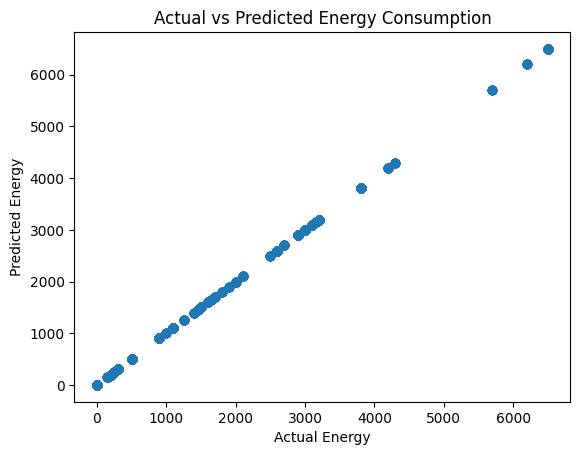

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Energy")
plt.ylabel("Predicted Energy")
plt.title("Actual vs Predicted Energy Consumption")
plt.show()

In [ ]:
importances = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df

,Feature,Importance
5,Heater Power[Watts],9.909299e-01
2,HV Battery SOC[%],6.742299e-03
4,Air Conditioning Power[Watts],1.995306e-03
1,Engine RPM[RPM],3.325184e-04
0,Vehicle Speed[km/h],1.994026e-08
3,Fuel Rate[L/hr],0.000000e+00


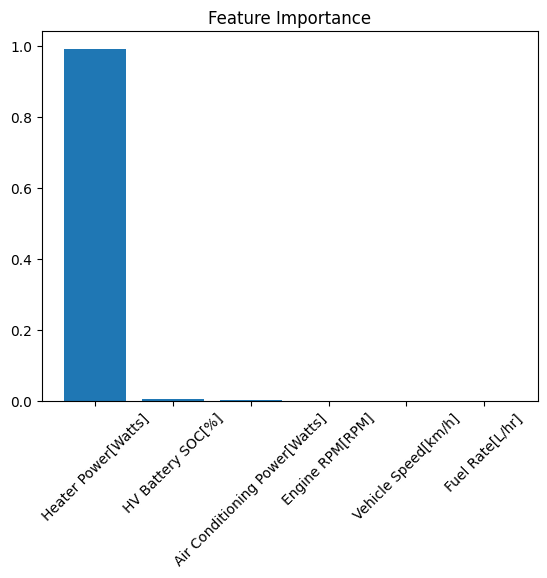

In [ ]:
plt.figure()
plt.bar(importance_df['Feature'], importance_df['Importance'])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

Correlation Matrix:
                                    DayNum     VehId      Trip  Timestamp(ms)  \
DayNum                            1.000000  0.023665  0.043566       0.023972   
VehId                             0.023665  1.000000  0.077950       0.164507   
Trip                              0.043566  0.077950  1.000000       0.056469   
Timestamp(ms)                     0.023972  0.164507  0.056469       1.000000   
Latitude[deg]                    -0.018183  0.006005  0.144161       0.158815   
Longitude[deg]                    0.028616  0.088265  0.063418       0.024017   
Vehicle Speed[km/h]               0.074958  0.027202  0.181538      -0.038489   
MAF[g/sec]                        0.001145  0.026059  0.184468      -0.018915   
Engine RPM[RPM]                   0.095842 -0.030284  0.127915      -0.041520   
Absolute Load[%]                 -0.018348  0.105068  0.062572      -0.007138   
OAT[DegC]                        -0.503613  0.141654  0.167775       0.053795   
Fuel Rat

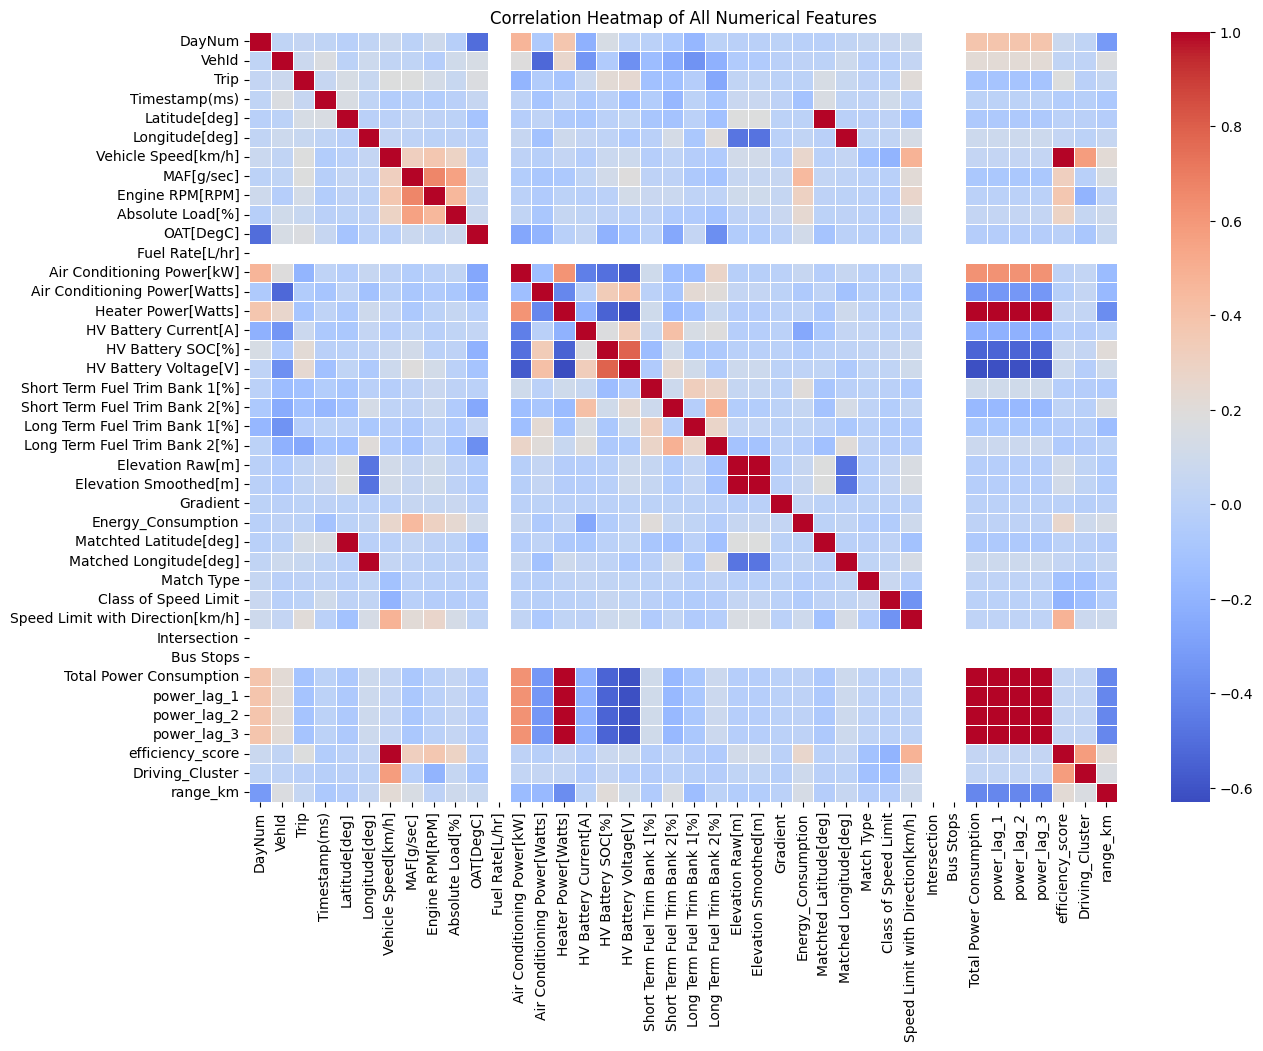

In [ ]:
# ==============================
# Correlation Heatmap (All Numerical Columns)
# ==============================
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

print("Correlation Matrix:")
print(corr_matrix)

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of All Numerical Features")
plt.show()

In [ ]:
df.shape

(118324, 43)